In [4]:
# Install the Azure Machine Learning SDK

%pip install azure-ai-ml azure-identity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 115.8 MB/s  0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.2.2
    Uninstalling psutil-5.2.2:
      Successfully uninstalled psutil-5.2.2
  Attempting uninstall: opentelemetry-api━━━━━━━━━━━━━━━━━━━━━━━━━  4/28 [asgiref]
    Found existing installation: opentelemetry-api 1.33.0━━━━━  4/28 [asgiref]
    Uninstalling opentelemetry-api-1.33.0:━━━━━━━━━━━━━━━━━━━━━━━━  6/28 [opentelemetry-api]
      Successfully uninstalled opentelemetry-api-1.33.0━━━━━━━━━━━  6/28 [opentelemetry-api]
  Attempting uninstall: opentelemetry-semantic-conventions━━━━  6/28 [opentelemetry-api]
    Found existing installation: opentelemetry-semantic-conventions 0.54b0/28 [opentelemetry-api]
    Uninstalling opentelemetry-semantic-conventions-0.54b0:━━━  6/28 [opentelemetry-api]
      Successfully uninstalled opentelemetry-semantic-conventions-0.54b0 6/28 [opentelemetry-api]
  Attempting uninstall: azure-storage-blob━━━━━━━

In [2]:
# 1. SETUP & IMPORTS

import pandas as pd             # For handling data tables
import matplotlib.pyplot as plt # For drawing charts
import tensorflow as tf         # The "AI engine"
from tensorflow.keras import layers # The building blocks of AI
from azure.ai.ml import MLClient    # To talk to Azure
from azure.identity import DefaultAzureCredential # For security

print("Setup Complete! TensorFlow Version:", tf.__version__)

Setup Complete! TensorFlow Version: 2.15.0


In [3]:
# 2. DATA INGESTION

try:
    # 1. Connect to the Azure Workspace
    credential = DefaultAzureCredential()
    ml_client = MLClient.from_config(credential)
    
    # 2. Grab the 'Fraud-Data' asset i created
    data_asset = ml_client.data.get(name="Fraud-Data", version="1")

    # 3. Read the data into a 'DataFrame' (a virtual spreadsheet)
    df = pd.read_csv(data_asset.path)

    print("✅ Success: Data loaded from Azure Cloud!")
    print(f"Total Transactions: {df.shape[0]}")
    print(f"Total Features (Clues): {df.shape[1]}")

except Exception as e:
    print("❌ Error: Could not find the data. Check the name in Azure Studio.")
    print(e)

Found the config file in: /config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Overriding of current MeterProvider is not allowed
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instru

✅ Success: Data loaded from Azure Cloud!
Total Transactions: 284807
Total Features (Clues): 31


Normal Transactions (Class 0): 284315
Fraudulent Transactions (Class 1): 492
Percentage of Fraud: 0.17%


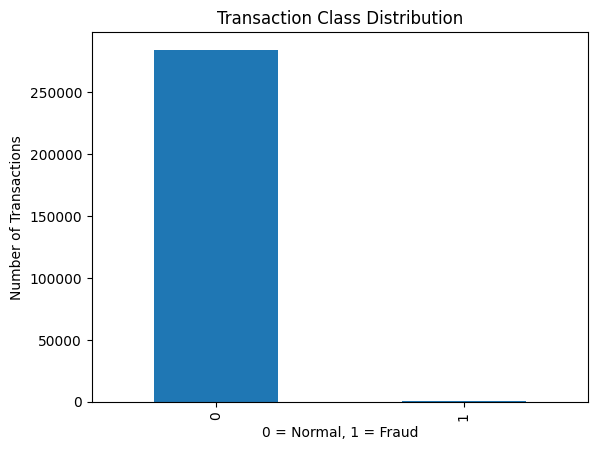

In [4]:
# 3. DATA EXPLORATION

# Let's count how many transactions are Normal (0) vs Fraud (1)
counts = df['Class'].value_counts()
fraud_percentage = (counts[1] / len(df)) * 100

print(f"Normal Transactions (Class 0): {counts[0]}")
print(f"Fraudulent Transactions (Class 1): {counts[1]}")
print(f"Percentage of Fraud: {fraud_percentage:.2f}%")

# Create a quick visual to show the imbalance

df['Class'].value_counts().plot(kind='bar', title='Transaction Class Distribution')
plt.xlabel('0 = Normal, 1 = Fraud')
plt.ylabel('Number of Transactions')
plt.show()

In [5]:
# 4. PREPROCESSING & DATA SPLITTING

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Scale the 'Amount' column
# I use a StandardScaler to make the numbers small (centered around 0)
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# 2. Define my X (Clues) and y (Answer)
# I drop 'Time' (not very useful) and the old 'Amount' (since we have the scaled one)
# I also drop 'Class' because that is the 'Answer' we want the AI to predict
X = df.drop(['Class', 'Time', 'Amount'], axis=1)
y = df['Class']

# 3. Split the data: 80% for Training, 20% for Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Preprocessing Complete!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

✅ Preprocessing Complete!
Training samples: 227845
Testing samples: 56962


In [6]:
# 5. BUILDING THE NEURAL NETWORK

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the "Architecture"
model = Sequential([
    # Input + First Hidden Layer: 32 neurons
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    
    # Second Hidden Layer: 16 neurons
    Dense(16, activation='relu'),
    
    # Dropout Layer: Helps the AI generalize better
    Dropout(0.5),
    
    # Output Layer: Sigmoid turns the result into a probability (0 to 1)
    Dense(1, activation='sigmoid')
])

# Compile: Tell the AI how to measure its mistakes (Loss) 
# and how to improve (Optimizer)
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

print("✅ Neural Network Architecture Created!")
model.summary() # This prints a map of the brain we just built

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Neural Network Architecture Created!


2026-03-03 05:32:03.707745: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,505 (5.88 KB)

 Trainable params: 1,505 (5.88 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 6. TRAINING THE NEURAL NETWORK


# I train for 10 'epochs' (rounds). 
# A batch_size of 32 means it looks at 32 transactions, 
# calculates the error, and adjusts its internal 'params'.

print("Starting training... this should take about 1-2 minutes on your CPU.")

history = model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=32, 
    validation_split=0.2, # I use 20% of training data to check progress
    verbose=1            # This shows the progress bar
)

print("\n✅ Training Complete!")

Starting training... this should take about 1-2 minutes on your CPU.
Epoch 1/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9980 - loss: 0.0138 - val_accuracy: 0.9994 - val_loss: 0.0035
Epoch 2/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9991 - loss: 0.0050 - val_accuracy: 0.9994 - val_loss: 0.0036
Epoch 3/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9991 - loss: 0.0050 - val_accuracy: 0.9987 - val_loss: 0.0040
Epoch 4/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9991 - loss: 0.0044 - val_accuracy: 0.9994 - val_loss: 0.0033
Epoch 5/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9991 - loss: 0.0043 - val_accuracy: 0.9993 - val_loss: 0.0034
Epoch 6/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9991 - loss: 0.0038 - val_accuracy: 0.9994 - val_loss: 0.0034
Epoch 7/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9991 - loss: 0.0043 - val_accuracy: 0.9994 - val_loss: 0.0033
Epoch 8/10
569

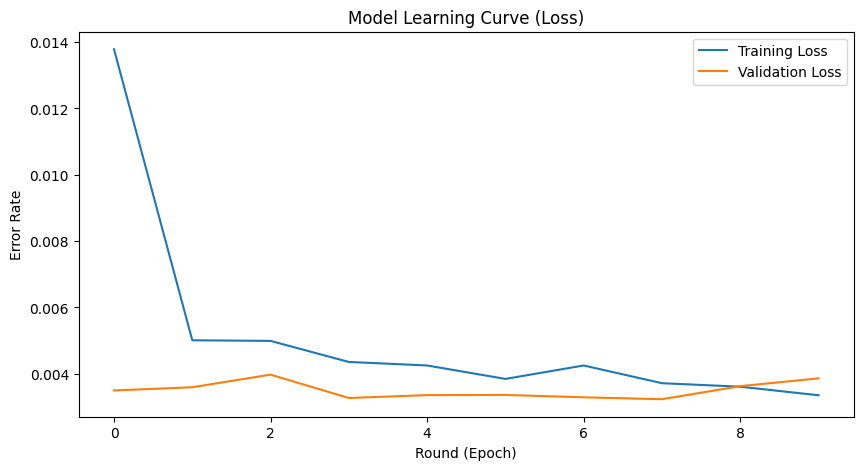

In [8]:
# 7. EVALUATING THE LEARNING CURVE


plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Learning Curve (Loss)')
plt.ylabel('Error Rate')
plt.xlabel('Round (Epoch)')
plt.legend()
plt.show()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 927us/step


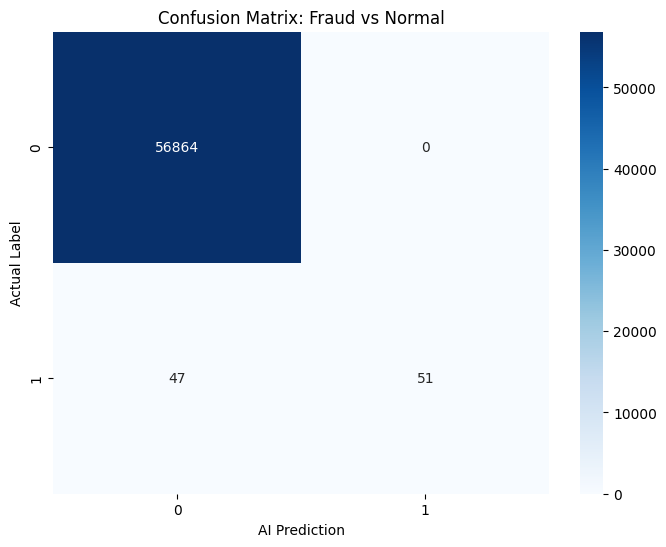


Detailed Performance Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       1.00      0.52      0.68        98

    accuracy                           1.00     56962
   macro avg       1.00      0.76      0.84     56962
weighted avg       1.00      1.00      1.00     56962



In [9]:
# 8. THE FINAL EXAM (EVALUATION)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Ask the AI to predict on the 'Hidden' 20% of data
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Visualize it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Fraud vs Normal')
plt.ylabel('Actual Label')
plt.xlabel('AI Prediction')
plt.show()

# 4. Detailed Report (Precision & Recall)
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

In [11]:
# 9. SAVING THE MODEL FOR DEPLOYMENT

# Saving the model in 'H5' format (standard for Keras/TensorFlow)
model.save('fraud_model.h5')

# Saving the scaler too, I need it to clean data on the website later.
import joblib
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and Scaler saved successfully! You can see them in your file list on the left.")

✅ Model and Scaler saved successfully! You can see them in your file list on the left.


In [12]:
# Saving in the modern 'Native Keras' format as recommended by the warning
model.save('fraud_model.keras')

print("✅ Modern Model saved as 'fraud_model.keras'!")

✅ Modern Model saved as 'fraud_model.keras'!
